# Full non-collinear electron and Nambu formalism
`add_exchange` accepts either a fixed 3-vector or a function `r -> [mx,my,mz]`, so the local
moment direction can vary from site to site (non-collinear magnetism). Combined with the Nambu
basis and a triplet pairing channel, this is the full non-collinear BdG formalism used for
non-unitary spin-triplet superconductivity.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import islands

In [2]:
g = geometry.triangular_lattice()
h = g.get_hamiltonian()
h.add_exchange([1.,1.,1.]) # exchange field (uniform direction here; could be r-dependent)
h.setup_nambu_spinor()     # initialize the non-collinear Nambu basis
h = h.get_mean_field_hamiltonian(V1=-1.0,filling=0.3,mf="random") # self-consistent triplet SC
d = h.get_dvector_non_unitarity() # non-unitarity of the spin-triplet d-vector
print("non-unitarity of the d-vector:", d)

non-unitarity of the d-vector: [[-0.00678561 -0.00678561 -0.00678561]]


### Band structure of the self-consistent superconductor
The pairing mixes the electron and hole copies of the bands only close to the Fermi energy, where
it opens a gap. Coloring each state by its electron weight makes this visible: far from the Fermi
energy the states are either electrons or holes, and at the gap edges they are a mixture of both.

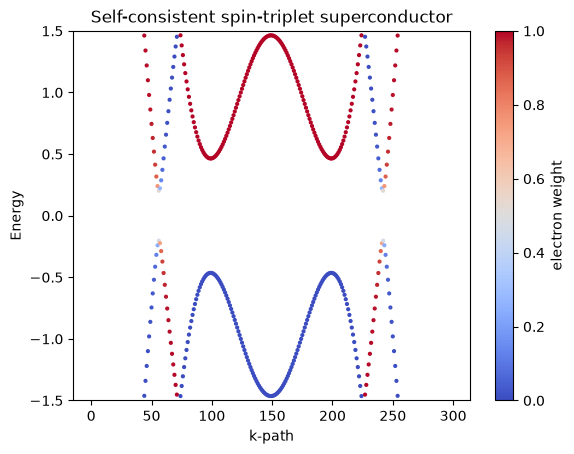

In [3]:
(k,e,c) = h.get_bands(operator="electron",nk=300) # bands and electron weight of each state

plt.scatter(k,e,c=c,cmap="coolwarm",s=4,vmin=0,vmax=1)
plt.colorbar(label="electron weight")
plt.ylim(-1.5,1.5) # zoom in around the Fermi energy
plt.xlabel("k-path") ; plt.ylabel("Energy")
plt.title("Self-consistent spin-triplet superconductor")
plt.show()